# 02 — Model Training: MeMPtec reproduction across both label views

Five model families (SVM, GLM, GBM, DRF, DL) x three feature sets (ETM / DTM / both) x two
class ratios (1:1, 1:10) under 5-fold stratified CV with a 70:10:20 split; the validation fold
selects the operating threshold. Reads notebook 01's artifacts; writes `training_results.csv`
and `best_model.json`.


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             roc_auc_score, average_precision_score, precision_recall_curve)

from common import (ECO_TITLES, MIN_VIEW_POS, SEED, make_models, make_views,
                    read_csv_literal)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]
N_FOLDS   = 5
VAL_FRACTION = 0.125          # 10/80 -> overall 70:10:20
IMBALANCE_RATIO = 10          # negatives per positive in the "imbalanced" variant

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
OUT_DIR = ROOT / "data" / "output" / ECO / "02_model_training"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["SVM", "GLM", "GBM", "DRF", "DL"]
FS_ORDER    = ["MeMPtec_E", "MeMPtec_D", "MeMPtec"]
METRICS     = ["precision", "recall", "f1", "accuracy", "rmse"]

t_nb = time.time()
print(f"{ECO_TITLE} | prep: {PREP.resolve()}")


npm | prep: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\01_data_prep


## 2. Load the prepared corpus

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
df = read_csv_literal(PREP / "model_ready_dataset.csv")

ETM_FEATURES = schema["etm_features"]
DTM_FEATURES = schema["dtm_features"]
FEATURE_SETS = {"MeMPtec_E": ETM_FEATURES,
                "MeMPtec_D": DTM_FEATURES,
                "MeMPtec":   ETM_FEATURES + DTM_FEATURES}

assert schema["ecosystem"] == ECO and len(df) == schema["n_packages"]
assert all(f in df.columns for f in schema["meta_features"])
label_arr = df["label"].astype(int).to_numpy()

VIEWS = make_views(label_arr)

print(f"{ECO_TITLE}: {len(df):,} packages | "
      f"ETM {len(ETM_FEATURES)} | DTM {len(DTM_FEATURES)} | MeMPtec {len(FEATURE_SETS['MeMPtec'])}")
for name, v in VIEWS.items():
    n, p = int(v["keep"].sum()), int(v["y"].sum())
    print(f"  view {name:12s}: {n:,} rows | {p:,} positives ({100*p/n:.2f}%)")
skipped = [k for k in ("compromised", "risky") if k not in VIEWS]
if skipped:
    print(f"  SKIPPED (fewer than {MIN_VIEW_POS} positives): {skipped}")
n_nan = int(df[schema['meta_features']].isna().sum().sum())
print(f"  NaN values carried in from notebook 01: {n_nan:,}")

npm: 101,350 packages | ETM 36 | DTM 20 | MeMPtec 56
  view compromised : 98,419 rows | 2,154 positives (2.19%)
  view risky       : 101,350 rows | 5,085 positives (5.02%)
  NaN values carried in from notebook 01: 114,055


## 3. Model factory

In [3]:
NEEDS_IMPUTER = {"SVM", "GLM", "DL"}
for name, m in make_models().items():
    has = isinstance(m, Pipeline) and "impute" in m.named_steps
    assert has == (name in NEEDS_IMPUTER), name
print("Model factory ready:", list(make_models().keys()))
print("  imputed (median, train-fold only):", sorted(NEEDS_IMPUTER))
print("  native NaN                       :", sorted(set(MODEL_ORDER) - NEEDS_IMPUTER))

Model factory ready: ['SVM', 'GLM', 'GBM', 'DRF', 'DL']
  imputed (median, train-fold only): ['DL', 'GLM', 'SVM']
  native NaN                       : ['DRF', 'GBM']


## 4. Metrics and the cross-validation protocol

In [4]:
def prepare_Xy(sub, features, y):
    X = sub[features].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)
    return X, y.astype(int)


def best_threshold(y_val, p_val):
    # threshold maximising F1 on the validation fold
    if len(np.unique(y_val)) < 2:
        return 0.5
    prec, rec, thr = precision_recall_curve(y_val, p_val)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    if len(thr) == 0:
        return 0.5
    return float(thr[int(np.argmax(f1[:-1]))])


def compute_metrics(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "accuracy":  accuracy_score(y_true, y_pred),
        "rmse":      float(np.sqrt(np.mean((y_proba - y_true) ** 2))),
        "roc_auc":   roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc":    average_precision_score(y_true, y_proba),
        "f1_at_0.5": f1_score(y_true, (y_proba >= 0.5).astype(int), pos_label=1, zero_division=0),
        "threshold": thr,
    }


def run_cv(X, y, model_name, n_splits=N_FOLDS):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    folds = []
    for tv_idx, te_idx in skf.split(X, y):
        X_tv, y_tv = X[tv_idx], y[tv_idx]
        X_te, y_te = X[te_idx], y[te_idx]
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tv, y_tv, test_size=VAL_FRACTION, random_state=SEED, stratify=y_tv)
        model = make_models()[model_name]
        model.fit(X_tr, y_tr)
        thr = best_threshold(y_val, model.predict_proba(X_val)[:, 1])
        folds.append(compute_metrics(y_te, model.predict_proba(X_te)[:, 1], thr))
    out = {}
    for k in folds[0]:
        vals = [f[k] for f in folds]
        out[f"{k}_mean"] = float(np.mean(vals))
        out[f"{k}_std"] = float(np.std(vals))
    return out


print("CV protocol defined: 70:10:20 per fold, threshold chosen on the validation split.")

CV protocol defined: 70:10:20 per fold, threshold chosen on the validation split.


## 5. Dataset variants

In [5]:
DATASETS = {}
rows = []
for vname, v in VIEWS.items():
    sub = df[v["keep"]].reset_index(drop=True)
    y = v["y"]
    pos_i = np.flatnonzero(y == 1); neg_i = np.flatnonzero(y == 0)
    r = np.random.default_rng(SEED)
    for variant, n_neg in [("balanced", len(pos_i)),
                           ("imbalanced", IMBALANCE_RATIO * len(pos_i))]:
        take = min(n_neg, len(neg_i))
        sel = np.sort(np.r_[pos_i, r.choice(neg_i, size=take, replace=False)])
        DATASETS[(vname, variant)] = (sub.iloc[sel].reset_index(drop=True), y[sel])
        rows.append({"view": vname, "variant": variant, "n_rows": len(sel),
                     "n_positive": len(pos_i), "n_negative": take,
                     "ratio_1_to": round(take / max(len(pos_i), 1), 2)})
variants_df = pd.DataFrame(rows)
print(variants_df.to_string(index=False))

       view    variant  n_rows  n_positive  n_negative  ratio_1_to
compromised   balanced    4308        2154        2154         1.0
compromised imbalanced   23694        2154       21540        10.0
      risky   balanced   10170        5085        5085         1.0
      risky imbalanced   55935        5085       50850        10.0


## 6. Training

In [6]:
records = []
t0 = time.time()
for (vname, variant), (sub, y) in DATASETS.items():
    for fs_name, features in FEATURE_SETS.items():
        X, yy = prepare_Xy(sub, features, y)
        for model_name in MODEL_ORDER:
            print(f"  [{vname:11s}/{variant:10s}] {model_name:4s} / {fs_name:10s} ... ",
                  end="", flush=True)
            ts = time.time()
            try:
                m = run_cv(X, yy, model_name)
                print(f"f1={m['f1_mean']:.4f}±{m['f1_std']:.4f}  "
                      f"pr_auc={m['pr_auc_mean']:.4f}  ({time.time()-ts:.1f}s)")
            except Exception as e:
                m = {}
                print(f"ERROR: {type(e).__name__}: {e}")
            records.append({"view": vname, "dataset": variant, "feature_set": fs_name,
                            "model": model_name, **m})
            # written after every configuration: a stall costs one config, not the whole run
            pd.DataFrame(records).to_csv(OUT_DIR / "training_results.csv", index=False)

results_df = pd.DataFrame(records)
results_df.to_csv(OUT_DIR / "training_results.csv", index=False)
n_failed = int(results_df["f1_mean"].isna().sum()) if "f1_mean" in results_df else len(results_df)
print(f"\n{len(results_df)} configurations, {n_failed} failed. "
      f"Total {(time.time()-t0)/60:.1f} min -> {OUT_DIR/'training_results.csv'}")

  [compromised/balanced  ] SVM  / MeMPtec_E  ... f1=0.8141±0.0142  pr_auc=0.8853  (1.2s)
  [compromised/balanced  ] GLM  / MeMPtec_E  ... f1=0.8161±0.0118  pr_auc=0.8847  (0.6s)
  [compromised/balanced  ] GBM  / MeMPtec_E  ... f1=0.8711±0.0102  pr_auc=0.9533  (10.1s)
  [compromised/balanced  ] DRF  / MeMPtec_E  ... f1=0.8762±0.0086  pr_auc=0.9527  (8.0s)
  [compromised/balanced  ] DL   / MeMPtec_E  ... f1=0.8389±0.0123  pr_auc=0.9100  (9.4s)
  [compromised/balanced  ] SVM  / MeMPtec_D  ... f1=0.8395±0.0083  pr_auc=0.8773  (0.9s)
  [compromised/balanced  ] GLM  / MeMPtec_D  ... f1=0.8402±0.0085  pr_auc=0.8768  (0.5s)
  [compromised/balanced  ] GBM  / MeMPtec_D  ... f1=0.9358±0.0081  pr_auc=0.9814  (6.5s)
  [compromised/balanced  ] DRF  / MeMPtec_D  ... f1=0.9246±0.0077  pr_auc=0.9794  (5.2s)
  [compromised/balanced  ] DL   / MeMPtec_D  ... f1=0.8885±0.0127  pr_auc=0.9427  (9.8s)
  [compromised/balanced  ] SVM  / MeMPtec    ... f1=0.8685±0.0070  pr_auc=0.9400  (0.9s)
  [compromised/balan

## 7. Results

In [7]:
def show(vname, variant):
    sub = results_df[(results_df.view == vname) & (results_df.dataset == variant)]
    out = []
    for _, r in sub.iterrows():
        row = {"Model": r["model"], "Features": r["feature_set"]}
        for m in METRICS:
            row[m.capitalize()] = f"{r[f'{m}_mean']:.4f} ± {r[f'{m}_std']:.4f}"
        row["F1@0.5"] = f"{r['f1_at_0.5_mean']:.4f}"
        row["Thr"] = f"{r['threshold_mean']:.3f}"
        out.append(row)
    disp = pd.DataFrame(out).set_index(["Model", "Features"])
    print(f"\n{'='*96}\n{vname.upper()}  /  {variant.upper()}\n{'='*96}")
    display(disp)

for vname in VIEWS:
    for variant in ["balanced", "imbalanced"]:
        show(vname, variant)


COMPROMISED  /  BALANCED


,,Precision,Recall,F1,Accuracy,Rmse,F1@0.5,Thr
Model,Features,,,,,,,
SVM,MeMPtec_E,0.8235 ± 0.0176,0.8055 ± 0.0252,0.8141 ± 0.0142,0.8162 ± 0.0131,0.3654 ± 0.0092,0.8106,0.417
GLM,MeMPtec_E,0.8306 ± 0.0199,0.8027 ± 0.0201,0.8161 ± 0.0118,0.8192 ± 0.0117,0.3651 ± 0.0101,0.8172,0.448
GBM,MeMPtec_E,0.9100 ± 0.0239,0.8361 ± 0.0170,0.8711 ± 0.0102,0.8763 ± 0.0106,0.3007 ± 0.0133,0.8753,0.572
DRF,MeMPtec_E,0.8951 ± 0.0170,0.8593 ± 0.0312,0.8762 ± 0.0086,0.8788 ± 0.0055,0.3029 ± 0.0081,0.8812,0.507
DL,MeMPtec_E,0.8295 ± 0.0310,0.8500 ± 0.0231,0.8389 ± 0.0123,0.8366 ± 0.0151,0.3448 ± 0.0089,0.8396,0.455
SVM,MeMPtec_D,0.7921 ± 0.0333,0.8955 ± 0.0319,0.8395 ± 0.0083,0.8285 ± 0.0142,0.3533 ± 0.0104,0.8418,0.481
GLM,MeMPtec_D,0.7931 ± 0.0218,0.8942 ± 0.0164,0.8402 ± 0.0085,0.8298 ± 0.0117,0.3536 ± 0.0106,0.8411,0.490
GBM,MeMPtec_D,0.9334 ± 0.0266,0.9392 ± 0.0147,0.9358 ± 0.0081,0.9355 ± 0.0092,0.2200 ± 0.0103,0.9359,0.474
DRF,MeMPtec_D,0.9319 ± 0.0194,0.9188 ± 0.0309,0.9246 ± 0.0077,0.9253 ± 0.0061,0.2467 ± 0.0070,0.9273,0.519



COMPROMISED  /  IMBALANCED


,,Precision,Recall,F1,Accuracy,Rmse,F1@0.5,Thr
Model,Features,,,,,,,
SVM,MeMPtec_E,0.4927 ± 0.0127,0.6583 ± 0.0295,0.5632 ± 0.0134,0.9072 ± 0.0030,0.2373 ± 0.0036,0.3966,0.258
GLM,MeMPtec_E,0.4892 ± 0.0199,0.6662 ± 0.0298,0.5634 ± 0.0109,0.9061 ± 0.0050,0.3483 ± 0.0046,0.4951,0.761
GBM,MeMPtec_E,0.7971 ± 0.0300,0.7410 ± 0.0262,0.7671 ± 0.0091,0.9591 ± 0.0020,0.1766 ± 0.0059,0.7565,0.320
DRF,MeMPtec_E,0.8536 ± 0.0165,0.7507 ± 0.0254,0.7988 ± 0.0207,0.9656 ± 0.0033,0.1737 ± 0.0058,0.7764,0.376
DL,MeMPtec_E,0.7060 ± 0.0463,0.6732 ± 0.0298,0.6881 ± 0.0276,0.9444 ± 0.0062,0.2053 ± 0.0067,0.6799,0.396
SVM,MeMPtec_D,0.4229 ± 0.0201,0.5975 ± 0.0375,0.4939 ± 0.0078,0.8887 ± 0.0065,0.2469 ± 0.0012,0.2775,0.265
GLM,MeMPtec_D,0.4076 ± 0.0075,0.6300 ± 0.0311,0.4944 ± 0.0062,0.8830 ± 0.0037,0.3768 ± 0.0025,0.4290,0.759
GBM,MeMPtec_D,0.9171 ± 0.0232,0.8487 ± 0.0172,0.8812 ± 0.0113,0.9792 ± 0.0021,0.1299 ± 0.0036,0.8784,0.407
DRF,MeMPtec_D,0.9068 ± 0.0232,0.8412 ± 0.0335,0.8720 ± 0.0123,0.9776 ± 0.0018,0.1377 ± 0.0046,0.8610,0.371



RISKY  /  BALANCED


,,Precision,Recall,F1,Accuracy,Rmse,F1@0.5,Thr
Model,Features,,,,,,,
SVM,MeMPtec_E,0.5787 ± 0.0214,0.8680 ± 0.0393,0.6935 ± 0.0114,0.6162 ± 0.0245,0.4570 ± 0.0051,0.6468,0.357
GLM,MeMPtec_E,0.5806 ± 0.0195,0.8645 ± 0.0374,0.6938 ± 0.0092,0.6184 ± 0.0212,0.4569 ± 0.0052,0.6486,0.355
GBM,MeMPtec_E,0.6575 ± 0.0399,0.8338 ± 0.0516,0.7326 ± 0.0057,0.6953 ± 0.0243,0.4199 ± 0.0042,0.7103,0.359
DRF,MeMPtec_E,0.6829 ± 0.0251,0.8197 ± 0.0350,0.7439 ± 0.0020,0.7178 ± 0.0118,0.4124 ± 0.0027,0.7272,0.410
DL,MeMPtec_E,0.6515 ± 0.0342,0.7945 ± 0.0518,0.7137 ± 0.0139,0.6812 ± 0.0261,0.4394 ± 0.0073,0.6942,0.385
SVM,MeMPtec_D,0.6074 ± 0.0098,0.8376 ± 0.0318,0.7037 ± 0.0048,0.6475 ± 0.0066,0.4674 ± 0.0018,0.6733,0.406
GLM,MeMPtec_D,0.6060 ± 0.0085,0.8427 ± 0.0285,0.7047 ± 0.0056,0.6470 ± 0.0063,0.4674 ± 0.0017,0.6724,0.402
GBM,MeMPtec_D,0.7515 ± 0.0297,0.8110 ± 0.0417,0.7785 ± 0.0068,0.7695 ± 0.0095,0.3860 ± 0.0051,0.7719,0.430
DRF,MeMPtec_D,0.7635 ± 0.0307,0.8026 ± 0.0301,0.7813 ± 0.0043,0.7753 ± 0.0116,0.3843 ± 0.0042,0.7791,0.454



RISKY  /  IMBALANCED


,,Precision,Recall,F1,Accuracy,Rmse,F1@0.5,Thr
Model,Features,,,,,,,
SVM,MeMPtec_E,0.2539 ± 0.0145,0.4299 ± 0.0381,0.3177 ± 0.0063,0.8323 ± 0.0135,0.2740 ± 0.0005,0.0677,0.139
GLM,MeMPtec_E,0.2599 ± 0.0166,0.4224 ± 0.0360,0.3203 ± 0.0063,0.8368 ± 0.0156,0.4492 ± 0.0009,0.2982,0.631
GBM,MeMPtec_E,0.5039 ± 0.0682,0.4431 ± 0.0455,0.4651 ± 0.0087,0.9070 ± 0.0124,0.2472 ± 0.0015,0.3913,0.211
DRF,MeMPtec_E,0.6008 ± 0.0479,0.4553 ± 0.0245,0.5158 ± 0.0065,0.9222 ± 0.0050,0.2394 ± 0.0012,0.4392,0.269
DL,MeMPtec_E,0.4281 ± 0.0494,0.4037 ± 0.0241,0.4128 ± 0.0165,0.8952 ± 0.0106,0.2592 ± 0.0028,0.3360,0.234
SVM,MeMPtec_D,0.1895 ± 0.0102,0.3634 ± 0.0296,0.2483 ± 0.0079,0.8000 ± 0.0157,0.2823 ± 0.0003,0.0027,0.136
GLM,MeMPtec_D,0.1833 ± 0.0046,0.3943 ± 0.0656,0.2486 ± 0.0098,0.7846 ± 0.0247,0.4702 ± 0.0015,0.2509,0.610
GBM,MeMPtec_D,0.6255 ± 0.0483,0.5219 ± 0.0383,0.5661 ± 0.0094,0.9274 ± 0.0039,0.2287 ± 0.0012,0.5009,0.258
DRF,MeMPtec_D,0.6545 ± 0.0397,0.5381 ± 0.0316,0.5885 ± 0.0063,0.9316 ± 0.0036,0.2238 ± 0.0016,0.5479,0.309


In [8]:
# view-vs-view: does merging vulnerable into the positive class help or hurt?
if len(VIEWS) > 1:
    piv = (results_df.pivot_table(index=["dataset", "feature_set", "model"],
                                  columns="view", values="f1_mean")
           .reindex(FS_ORDER, level="feature_set").reindex(MODEL_ORDER, level="model"))
    piv["delta (risky - compromised)"] = piv["risky"] - piv["compromised"]
    piv.to_csv(OUT_DIR / "view_comparison.csv")
    print("F1 (positive class) by label view:")
    print(piv.to_string(float_format="{:.4f}".format))
    print(f"\nmean delta: {piv['delta (risky - compromised)'].mean():+.4f}  |  "
          f"risky wins in {int((piv['delta (risky - compromised)']>0).sum())} of {len(piv)} configs")
else:
    print(f"Only one usable label view for {ECO_TITLE} ({list(VIEWS)[0]}) — no comparison.")

F1 (positive class) by label view:
view                          compromised  risky  delta (risky - compromised)
dataset    feature_set model                                                 
balanced   MeMPtec_E   SVM         0.8141 0.6935                      -0.1205
                       GLM         0.8161 0.6938                      -0.1223
                       GBM         0.8711 0.7326                      -0.1386
                       DRF         0.8762 0.7439                      -0.1323
                       DL          0.8389 0.7137                      -0.1252
           MeMPtec_D   SVM         0.8395 0.7037                      -0.1358
                       GLM         0.8402 0.7047                      -0.1356
                       GBM         0.9358 0.7785                      -0.1573
                       DRF         0.9246 0.7813                      -0.1433
                       DL          0.8885 0.7447                      -0.1438
           MeMPtec     SVM   

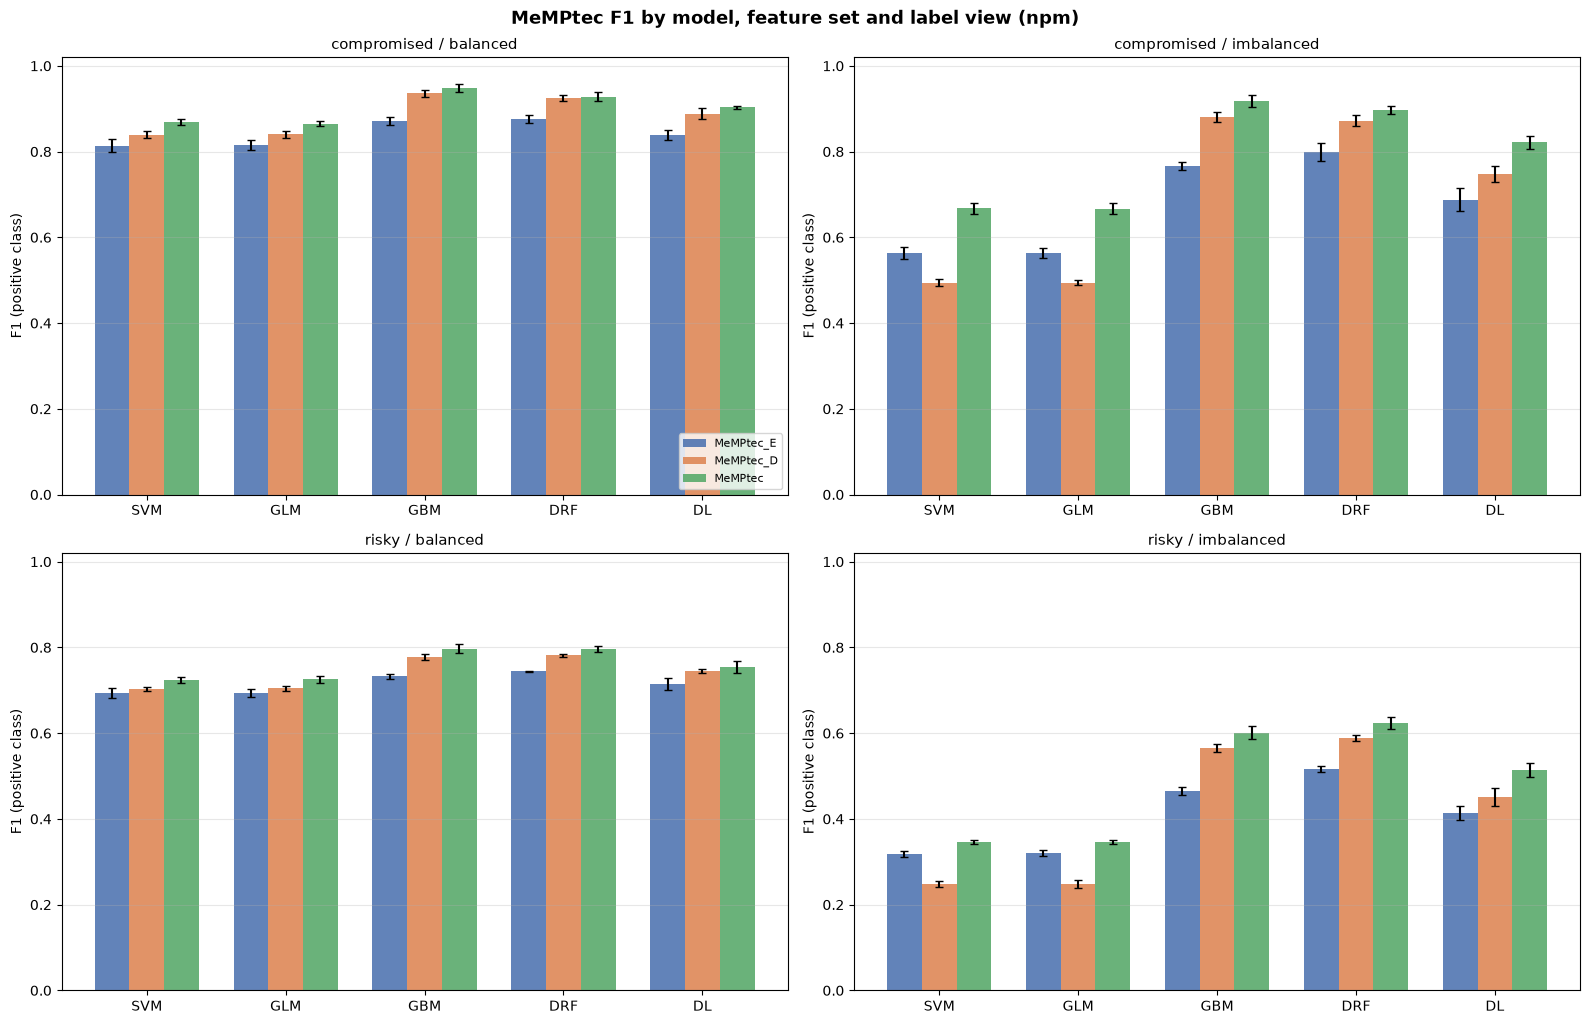

In [9]:
n_v = len(VIEWS)
fig, axes = plt.subplots(n_v, 2, figsize=(16, 5.2 * n_v), squeeze=False)
COLORS = ["#4C72B0", "#DD8452", "#55A868"]
for i, vname in enumerate(VIEWS):
    for j, variant in enumerate(["balanced", "imbalanced"]):
        ax = axes[i][j]
        sub = results_df[(results_df.view == vname) & (results_df.dataset == variant)]
        x = np.arange(len(MODEL_ORDER)); w = 0.25
        for k, (fs, c) in enumerate(zip(FS_ORDER, COLORS)):
            vals, errs = [], []
            for mo in MODEL_ORDER:
                r = sub[(sub.model == mo) & (sub.feature_set == fs)]
                vals.append(float(r["f1_mean"].iloc[0]) if len(r) else 0.0)
                errs.append(float(r["f1_std"].iloc[0]) if len(r) else 0.0)
            ax.bar(x + k * w, vals, w, yerr=errs, capsize=3, label=fs, color=c, alpha=0.88)
        ax.set_xticks(x + w); ax.set_xticklabels(MODEL_ORDER)
        ax.set_ylim(0, 1.02); ax.set_ylabel("F1 (positive class)")
        ax.set_title(f"{vname} / {variant}", fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc="lower right")
fig.suptitle(f"MeMPtec F1 by model, feature set and label view ({ECO_TITLE})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 8. Best configuration

In [10]:
best = {}
for vname in VIEWS:
    sub = results_df[(results_df.view == vname) & (results_df.dataset == "imbalanced")
                     & results_df["f1_mean"].notna()]
    if not len(sub):
        continue
    r = sub.sort_values(["f1_mean", "pr_auc_mean"], ascending=False).iloc[0]
    best[vname] = {"model": r["model"], "feature_set": r["feature_set"],
                   "f1_mean": float(r["f1_mean"]), "pr_auc_mean": float(r["pr_auc_mean"]),
                   "roc_auc_mean": float(r["roc_auc_mean"]),
                   "selected_on": "imbalanced variant, mean F1 then mean PR-AUC"}
    print(f"{vname:12s} -> {r['model']} / {r['feature_set']}  "
          f"F1={r['f1_mean']:.4f}  PR-AUC={r['pr_auc_mean']:.4f}  ROC-AUC={r['roc_auc_mean']:.4f}")

(OUT_DIR / "best_model.json").write_text(
    json.dumps({"ecosystem": ECO, "best_per_view": best}, indent=2), encoding="utf-8")
print(f"\nsaved {OUT_DIR/'best_model.json'}")

compromised  -> GBM / MeMPtec  F1=0.9181  PR-AUC=0.9678  ROC-AUC=0.9921
risky        -> DRF / MeMPtec  F1=0.6244  PR-AUC=0.6838  ROC-AUC=0.9015

saved ..\data\output\npm\02_model_training\best_model.json


## 9. Summary

In [12]:
summary = {"ecosystem": ECO, "n_configurations": len(results_df),
            "views": ",".join(VIEWS), "runtime_min": (time.time() - t_nb) / 60}
for vname in VIEWS:
    s = results_df[(results_df.view == vname) & (results_df.dataset == "imbalanced")]
    summary[f"{vname}_best_model"] = best.get(vname, {}).get("model", "n/a")
    summary[f"{vname}_best_fset"] = best.get(vname, {}).get("feature_set", "n/a")
    summary[f"{vname}_best_f1"] = round(float(s["f1_mean"].max()), 4)
    summary[f"{vname}_best_pr_auc"] = round(float(s["pr_auc_mean"].max()), 4)
    summary[f"{vname}_mean_f1_MeMPtec"] = round(
        float(s[s.feature_set == "MeMPtec"]["f1_mean"].mean()), 4)
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                    npm
n_configurations                              60
views                          compromised,risky
runtime_min                            15.571499
compromised_best_model                       GBM
compromised_best_fset                    MeMPtec
compromised_best_f1                       0.9181
compromised_best_pr_auc                   0.9678
compromised_mean_f1_MeMPtec               0.7941
risky_best_model                             DRF
risky_best_fset                          MeMPtec
risky_best_f1                             0.6244
risky_best_pr_auc                         0.6838
risky_mean_f1_MeMPtec                     0.4868
